In [36]:
import re
import time
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Pull the Data

In [37]:
# True = re-pull from nba_api / Basketball-Reference.com
REFRESH_DATA = False

In [38]:
# Salary cap data from Google search
CAP_2025_26 = 154_647_000
MIN_SALARY = {0: 1_272_870, 1: 2_048_494, 2: 2_296_274, 3: 2_378_870,
              4: 2_461_463, 5: 2_667_944, 6: 2_874_436, 7: 3_080_921,
              8: 3_287_409, 9: 3_303_774, 10: 3_634_153}   # 10 = 10+

In [39]:
def cba_min_salary(yos):
    return MIN_SALARY[min(int(yos), 10)]

def cba_max_salary(yos):
    pct = 0.25 if yos <= 6 else 0.30 if yos <= 9 else 0.35
    return round(pct * CAP_2025_26)

def pull_player_stats(season="2025-26"):
    """Season totals for every player (LeagueLeaders endpoint -> nba_player_stats_2026.csv format)."""
    from nba_api.stats.endpoints import leagueleaders
    df = leagueleaders.LeagueLeaders(season=season, per_mode48="Totals",
                                     stat_category_abbreviation="PTS").get_data_frames()[0]
    return df

def pull_physicals(season="2025-26", combine_years=range(2001, 2026), sleep=0.6):
    """Height/weight league-wide + combine wingspan (height-imputed where missing)
    + years of experience + CBA min/max salary  ->  nba_api.csv format."""
    from nba_api.stats.endpoints import (leaguedashplayerbiostats,
                                         draftcombineplayeranthro, commonallplayers)
    bio = leaguedashplayerbiostats.LeagueDashPlayerBioStats(season=season).get_data_frames()[0]
    bio = bio.rename(columns={"PLAYER_ID": "player_id", "PLAYER_NAME": "player", "AGE": "age",
                              "PLAYER_HEIGHT_INCHES": "height_in", "PLAYER_WEIGHT": "weight_lb"})
    bio = bio[["player_id", "player", "age", "height_in", "weight_lb"]].copy()
    bio["weight_lb"] = pd.to_numeric(bio["weight_lb"], errors="coerce")

    frames = []
    for year in combine_years:
        try:
            a = draftcombineplayeranthro.DraftCombinePlayerAnthro(
                league_id="00", season_year=str(year)).get_data_frames()[0]
            if len(a):
                frames.append(a)
        except Exception as e:
            print(f"  skip combine {year}: {e}")
        time.sleep(sleep)
    anthro = pd.concat(frames, ignore_index=True)
    anthro["WINGSPAN"] = pd.to_numeric(anthro["WINGSPAN"], errors="coerce")
    anthro = (anthro.dropna(subset=["WINGSPAN"]).drop_duplicates("PLAYER_ID")
              .rename(columns={"PLAYER_ID": "player_id", "WINGSPAN": "wingspan_in"})
              [["player_id", "wingspan_in"]])
    df = bio.merge(anthro, on="player_id", how="left")

    fit = df.dropna(subset=["wingspan_in", "height_in"])           # impute wingspan from height
    slope, intercept = np.polyfit(fit["height_in"], fit["wingspan_in"], 1)
    miss = df["wingspan_in"].isna()
    df.loc[miss, "wingspan_in"] = intercept + slope * df.loc[miss, "height_in"]

    exp = commonallplayers.CommonAllPlayers(is_only_current_season=1).get_data_frames()[0]
    exp["years_experience"] = 2025 - exp["FROM_YEAR"].astype(int)   # 0 = rookie in 2025-26
    df = df.merge(exp[["PERSON_ID", "years_experience"]],
                  left_on="player_id", right_on="PERSON_ID", how="left").drop(columns=["PERSON_ID"])
    df["min_salary"] = df["years_experience"].apply(cba_min_salary)
    df["max_salary"] = df["years_experience"].apply(cba_max_salary)
    return df

def pull_salaries():
    """2025-26 salaries from the Basketball-Reference contracts page -> nba_salaries.csv format."""
    import requests
    from io import StringIO
    url = "https://www.basketball-reference.com/contracts/players.html"
    html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
    return pd.read_html(StringIO(html), header=1)[0]

if REFRESH_DATA:
    pull_player_stats().to_csv(f"{DATA_DIR}/nba_player_stats_2026.csv", index=False)
    pull_physicals().to_csv(f"{DATA_DIR}/nba_api.csv", index=False)
    pull_salaries().to_csv(f"{DATA_DIR}/nba_salaries.csv", index=False)

In [40]:
# ---------- load ----------
stats = pd.read_csv(f"../Data/nba_player_stats_2026.csv").rename(columns={"PLAYER_ID": "player_id"})
bio   = pd.read_csv(f"../Data/nba_api.csv")
sal   = pd.read_csv(f"../Data/nba_salaries.csv")
print(f"stats {stats.shape} | bio {bio.shape} | salaries {sal.shape}")

stats (582, 28) | bio (582, 9) | salaries (530, 11)


In [41]:
# ---------- clean the salary table ----------
# Basketball-Reference.com embeds repeated header rows; salary is a "$12,345,678" string; traded players can repeat.
sal = sal[sal["Player"].notna() & (sal["Player"] != "Player")].copy()
sal["salary"] = pd.to_numeric(sal["2025-26"].astype(str).str.replace(r"[$,]", "", regex=True),
                              errors="coerce")
sal = (sal.dropna(subset=["salary"])
          .sort_values("salary", ascending=False)
          .drop_duplicates("Player"))
print(f"clean salary rows: {len(sal)}")

clean salary rows: 490


In [42]:
# ---------- merge the three tables ----------
# stats + bio share the nba_api player_id; BBRef has no id, so join on normalized names.
def norm(name):
    name = unicodedata.normalize("NFKD", str(name)).encode("ascii", "ignore").decode()
    name = re.sub(r"[.'`]", "", name.lower()).replace("-", " ")
    name = re.sub(r"\s+(jr|sr|ii|iii|iv|v)$", "", name.strip())
    return re.sub(r"\s+", " ", name).strip()

ALIASES = {"ronald holland": "ron holland"}   # nickname fixes found during matching

df = stats.merge(bio.drop(columns=["player"]), on="player_id", how="left")
df["key"]  = df["PLAYER"].map(norm).replace(ALIASES)
sal["key"] = sal["Player"].map(norm).replace(ALIASES)
df = df.merge(sal[["key", "salary"]], on="key", how="left").drop(columns=["key"])

df.head(5)

,player_id,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,AST_TOV,STL_TOV,age,height_in,weight_lb,wingspan_in,years_experience,min_salary,max_salary,salary
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,2.08,0.41,27.0,80,230.0,83.987946,7,3080921,46394100,45999660.0
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,2.97,0.63,27.0,78,195.0,83.500000,7,3080921,46394100,38333050.0
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,1.41,0.28,29.0,78,223.0,83.750000,9,3303774,46394100,53142264.0
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,1.51,0.25,37.0,83,240.0,88.750000,18,3634153,54126450,54708609.0
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,2.70,0.76,25.0,74,200.0,78.083276,5,2667944,38661750,37958760.0


In [43]:
#only weight_lb and salary have missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         582 non-null    int64  
 1   RANK              582 non-null    int64  
 2   PLAYER            582 non-null    object 
 3   TEAM_ID           582 non-null    int64  
 4   TEAM              582 non-null    object 
 5   GP                582 non-null    int64  
 6   MIN               582 non-null    int64  
 7   FGM               582 non-null    int64  
 8   FGA               582 non-null    int64  
 9   FG_PCT            582 non-null    float64
 10  FG3M              582 non-null    int64  
 11  FG3A              582 non-null    int64  
 12  FG3_PCT           582 non-null    float64
 13  FTM               582 non-null    int64  
 14  FTA               582 non-null    int64  
 15  FT_PCT            582 non-null    float64
 16  OREB              582 non-null    int64  
 1

# Drop unneeded fields

In [44]:
# Drop unneeded fields
df = df.drop(['player_id', 'RANK', 'TEAM_ID'], axis=1)

# Missing Weights

In [45]:
# Missing weight are mainly for two-way (G-League) contracts
no_weight = df[df["weight_lb"].isna()].sort_values("MIN", ascending=False)
print(f"players: {len(df)} | with weight: {df['weight_lb'].notna().sum()} | without: {len(no_weight)}")
no_weight[["PLAYER", "TEAM", "GP", "MIN", "weight_lb"]].head(10)

players: 582 | with weight: 576 | without: 6


,PLAYER,TEAM,GP,MIN,weight_lb
111,Jaylen Wells,MEM,69,1821,NaN
409,LJ Cryer,GSW,18,292,NaN
463,Chris Youngblood,POR,34,185,NaN
474,Tolu Smith,DET,15,137,NaN
536,Lawson Lovering,MEM,2,49,NaN
577,Jahmyl Telfort,LAC,8,32,NaN


In [46]:
# Only Jaylen Wells has significant minutes and is missing weight
# I looked up the weight for Jaylon Wells on https://www.basketball-reference.com/players/w/wellsja01.html and set manually
df.loc[111, 'weight_lb'] = 206

In [47]:
# I will impute the median weight for all other players
df['weight_lb'] = df['weight_lb'].fillna(df['weight_lb'].median())

In [48]:
# Verify the no_weight players now have a weight
df.loc[no_weight.index, ["PLAYER", "TEAM", "MIN", "weight_lb"]]

,PLAYER,TEAM,MIN,weight_lb
111,Jaylen Wells,MEM,1821,206.0
409,LJ Cryer,GSW,292,215.0
463,Chris Youngblood,POR,185,215.0
474,Tolu Smith,DET,137,215.0
536,Lawson Lovering,MEM,49,215.0
577,Jahmyl Telfort,LAC,32,215.0


# Missing Salaries

In [49]:
# Missing salaries are mainly for two-way (G-League) contracts
no_sal = df[df["salary"].isna()].sort_values("MIN", ascending=False)
print(f"players: {len(df)} | with salary: {df['salary'].notna().sum()} | without: {len(no_sal)}")
no_sal[["PLAYER", "TEAM", "GP", "MIN"]].head(10)   

players: 582 | with salary: 469 | without: 113


,PLAYER,TEAM,GP,MIN
218,Egor Dëmin,BKN,52,1308
274,Ryan Nembhard,DAL,60,1171
288,Jamir Watkins,WAS,50,1032
232,Caleb Love,POR,49,1013
358,Dylan Cardwell,SAC,44,907
253,Quenton Jackson,IND,49,897
301,Daeqwon Plowden,SAC,32,844
275,Javon Small,MEM,41,830
346,Pete Nance,MIL,47,737
311,Sharife Cooper,WAS,41,700


# Histograms

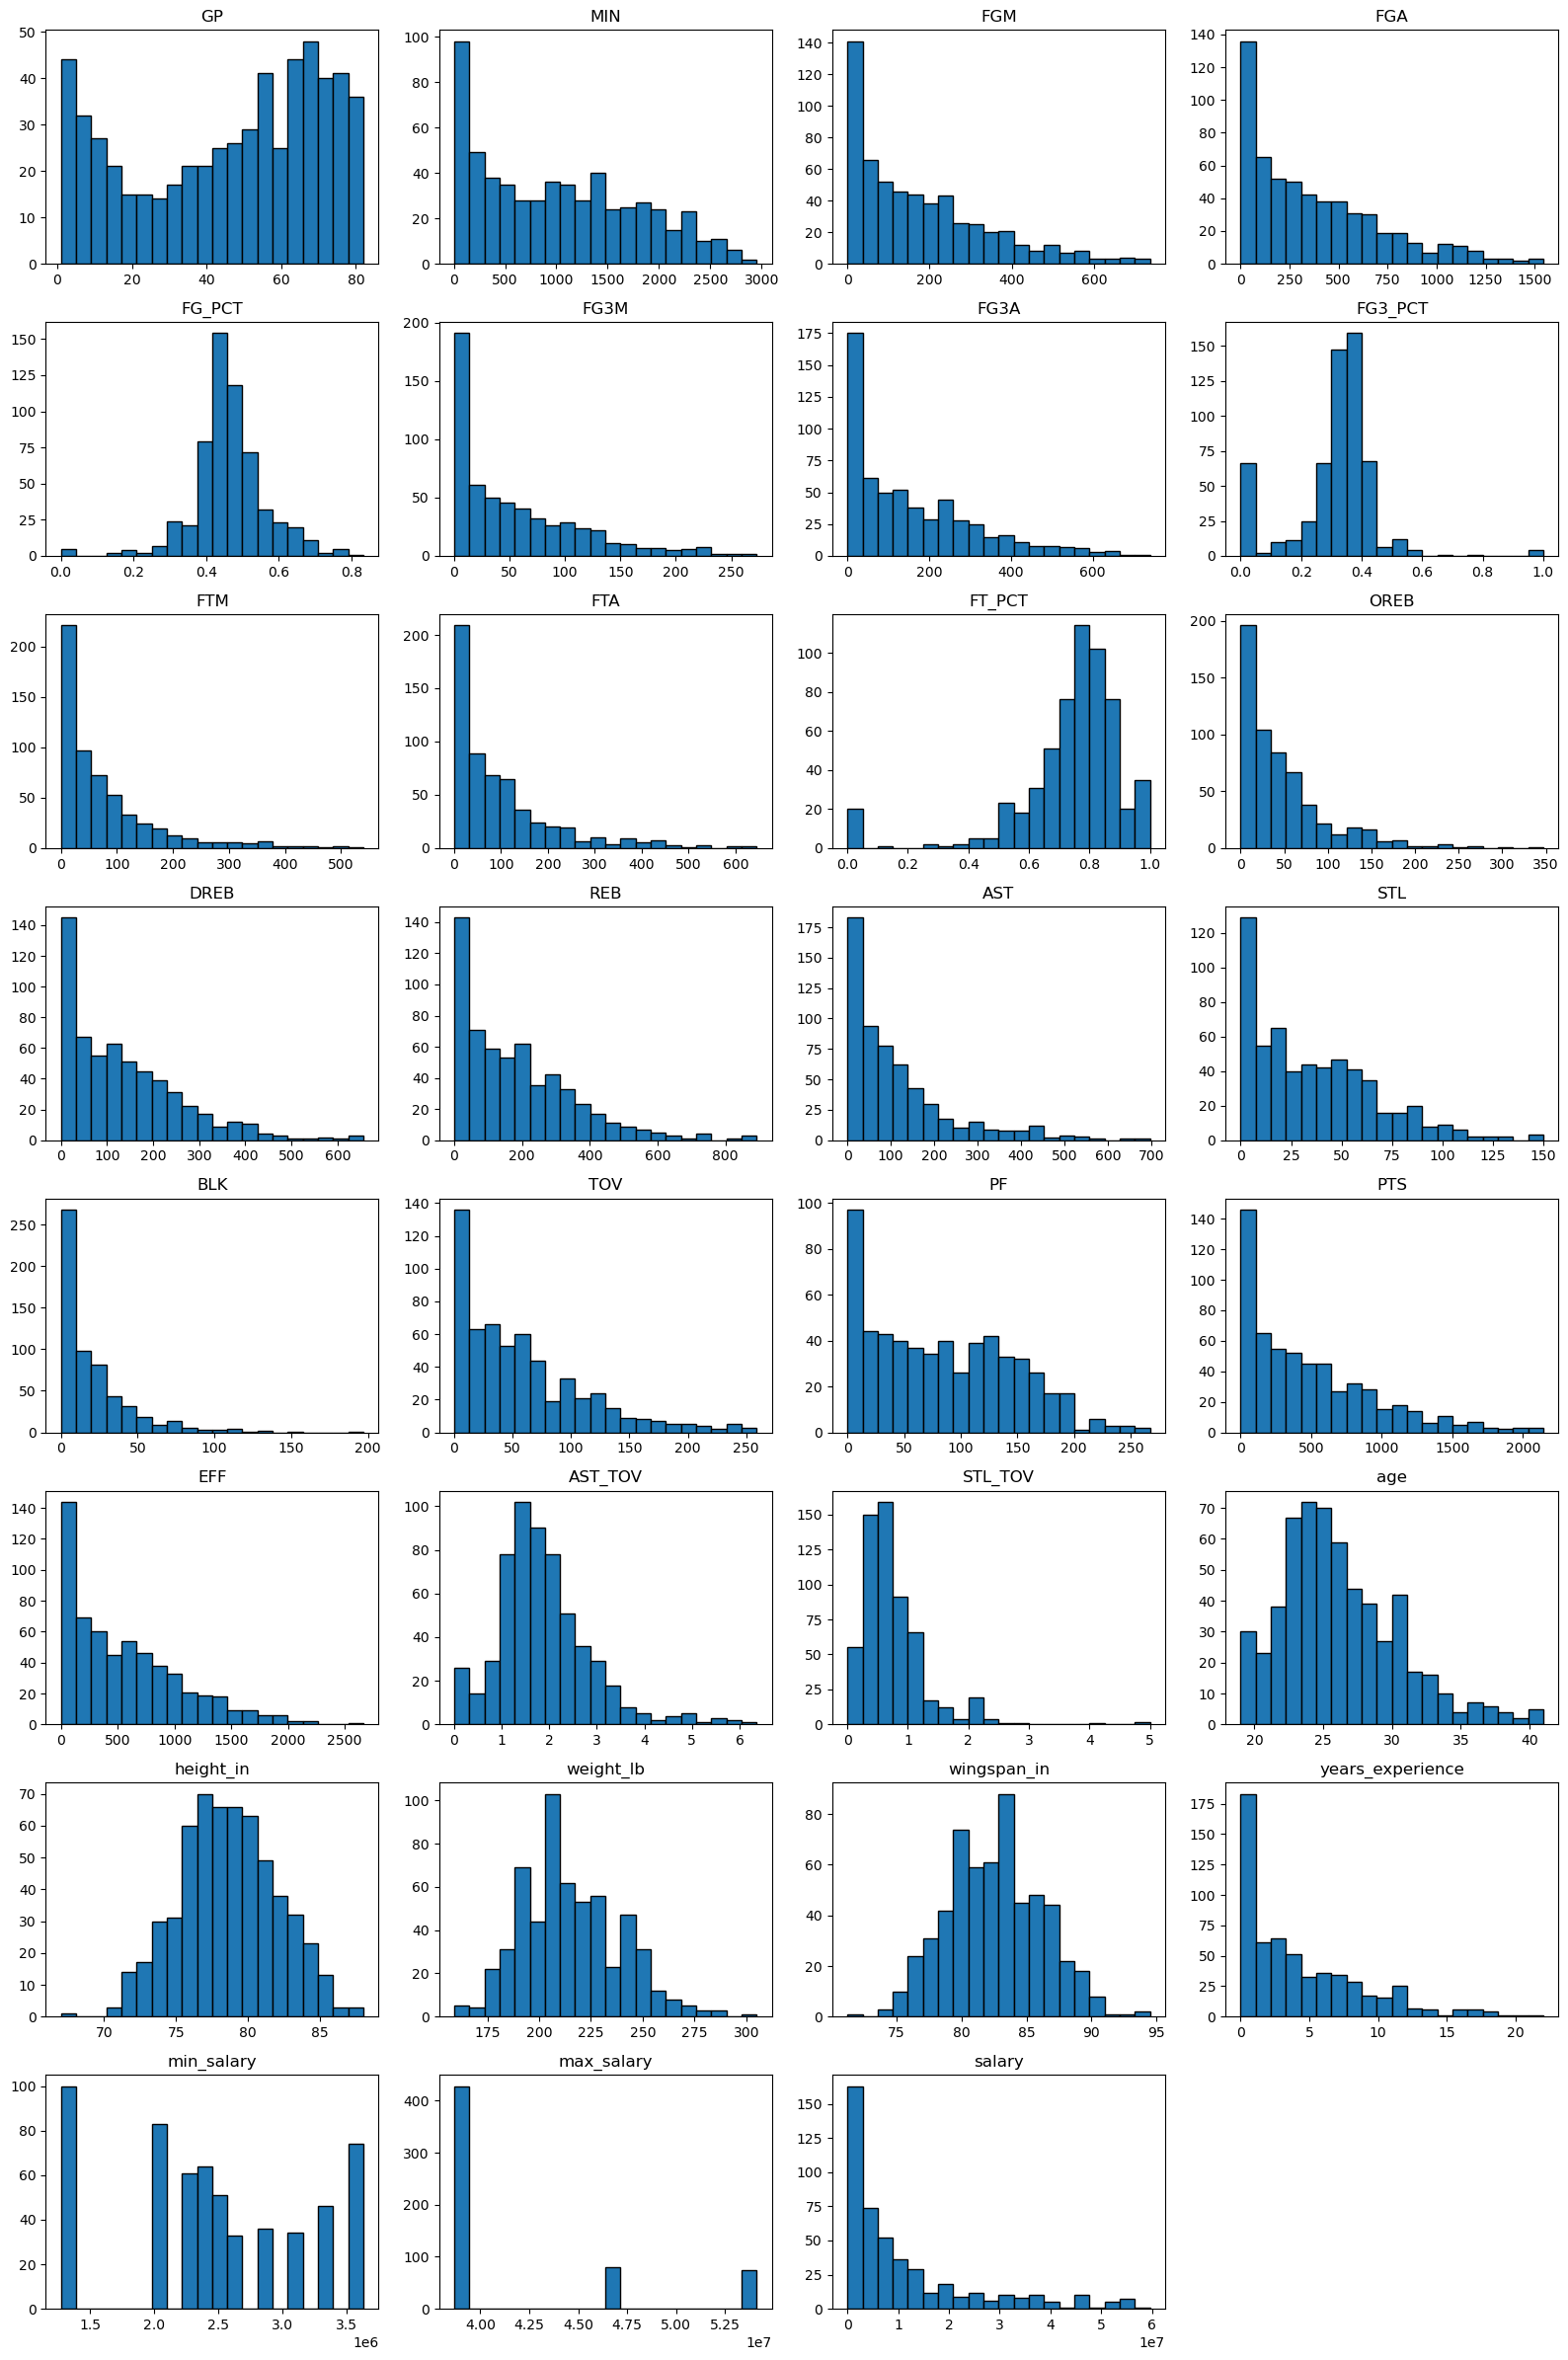

In [50]:
# Select only numerical columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Define grid dimensions (4 columns)
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Plot histograms in a grid format
df[numeric_cols].hist(
    figsize=(16, 3 * n_rows), 
    layout=(n_rows, n_cols), 
    bins=20, 
    edgecolor='black',
    grid=False
)

plt.tight_layout()
plt.show()

In [51]:
# make all columns lowercase for ease of use going forward
df.columns = df.columns.str.lower()

In [52]:
# save the data to a new csv file
filepath = (f"../Data/nba-1-data-wrangling.csv")
df.to_csv(filepath, index=False)

# Summary
<br> - Loaded data for salaries, physicals, and 2025-2026 regular season stats
<br> - Merged the datasets based on ID and name
<br> - Added weight for 6 missing players
<br> - Noted that 113 players are missing salaries. They will not be part of regression, but can be used in clustering
<br> - Plotted histograms for all numeric fields to get a sense of the data. 
<br> - These histograms have long right tails. Salary, min_salary, and max_salary indicate that there is a high concentration of players at the lower end of the financial scale either due to rookie contracts, veteran minimums, or mid-level exceptions
<br> - No players have been dropped yet. This will be determined in the next step: Exploratory Data Analysis (EDA)
